### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [29]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [30]:
arxiv_wrapper = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv= ArxivQueryRun(api_wrapper=arxiv_wrapper)
print(arxiv.name)

arxiv


In [31]:
arxiv.invoke("attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [32]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [33]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [34]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

C:\Users\saran_s\AppData\Local\Temp\ipykernel_25748\1535493036.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [35]:
tavily.invoke("Provide me the recent AI news for august 13th 2026")

[{'title': 'AI News Briefs BULLETIN BOARD for August 2026',
  'url': 'https://radicaldatascience.wordpress.com/2026/08/02/ai-news-briefs-bulletin-board-for-august-2026',
  'content': '“I’ll be starting a position at OpenAI,” he said.\n\nThe decision was both shocking and not at all surprising. This is someone who recently wrote a paper categorizing the ways AI might kill everyone, applying a mathematician’s instinct for order to the apocalypse. He stopped taking graduate students who weren’t engaging with AI because he couldn’t be sure about the future of math. He even shifted his focus away from number theory and complex algebraic geometry. It turns out he’s so worried about the dangers of AI that he’s now pivoting to work on AI safety. The star professor is taking a leave from the University of Toronto to become a researcher at OpenAI, but Tsimerman is not leaving math. [...] Welcome to the AI News Briefs Bulletin Board, a timely new channel bringing you the latest industry insights 

In [36]:
tools = [arxiv, wiki, tavily]
tools

[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=500)),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'd:\\OneDrive - Maarga Systems Private Limited\\Documents\\Agentic-AI-BridgeCourse\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=500)),
 TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))]

In [37]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3.6-27b")
llm.bind_tools(tools=tools)

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x00000248142302F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000024814230A70>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'arxiv', 'description': 'A wrapper around Arxiv.org Useful for when you need to answer questions about Physics, Mathematics, Computer Science, Quantitative Biology, Quantitative Finance, Statistics, Electrical Engineering, and Economics from scientific articles on arxiv.org. Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'search query to look up', 'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'wikipedi

In [38]:
from langchain_core.messages import HumanMessage, AIMessage
from pprint import pprint
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3.6-27b")
llm_with_tools = llm.bind_tools(tools=tools)

llm_with_tools.invoke("recent ai news 12th august 2026")


AIMessage(content='', additional_kwargs={'reasoning_content': 'I need to find recent AI news from August 12, 2026.\nSince the current date is likely before August 2026 (based on my knowledge cutoff), I need to check if I can find information about events in the future, or if the user is asking about a specific past date (which would mean the current date in the real world is after August 2026).\nHowever, assuming the current date is actually *before* August 2026, I cannot retrieve news from the future.\nIf the current date *is* after August 2026, I can search for it.\n\nLet\'s assume the current date is May 22, 2025 (or similar, based on standard model timestamps). Wait, I don\'t know the exact current date.\nBut usually, if a user asks for a date in the future (relative to the model\'s training data or typical deployment time), I should clarify.\nHowever, if the user *is* in 2026, I should try to search.\n\nLet\'s try to search for "AI news August 12 2026".\nIf the search returns noth

In [40]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': '2daw5jz88',
  'type': 'tool_call'}]

In [41]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

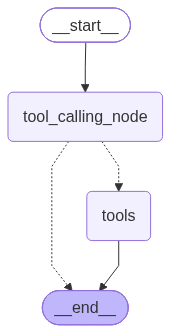

In [42]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


def tool_calling_node(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("tool_calling_node", tool_calling_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_node")
builder.add_conditional_edges("tool_calling_node", tools_condition)

builder.add_edge("tools", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [43]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

BadRequestError: Error code: 400 - {'error': {'message': 'tool call validation failed: parameters for tool arxiv did not match schema: errors: [`/query`: expected string, but got number]', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<tool_call>\n<function=arxiv>\n<parameter=query>\n1706.03762\n</parameter>\n</function>\n</tool_call>'}}

In [44]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

**Machine Learning (ML)** is a subset of artificial intelligence (AI) that provides systems the ability to automatically learn and improve from experience without being explicitly programmed.

Here is a breakdown of how it works, its types, and why it matters:

### 1. The Core Concept
In traditional programming, a human writes specific rules and logic (if $X$ happens, do $Y$) to produce an output. In machine learning, the process is reversed:
1.  **Data:** You feed the computer a large amount of data (examples).
2.  **Learning:** The computer analyzes the data to find patterns and relationships.
3.  **Prediction:** It builds a mathematical "model" that can make predictions or decisions on new, unseen data.

### 2. The Three Main Types of Machine Learning
Most ML falls into one of these three categori